# Set up
**Import libraries**

In [1]:
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from knmy import knmy
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    recall_score,
    roc_auc_score
)
from sklearn.preprocessing import RobustScaler
from scipy.spatial.distance import cdist

**Load and merge datasets**

In [2]:
# Load data
df = pd.read_csv("../data/bunny.csv", dtype={'Oryctolagus cuniculus': str})
habitat = pd.read_csv("../data/habitats.csv")

# Merge habitats with bunny data with only matching decimalLatitude and decimalLongitude values
df = df.merge(habitat, how="left", on=["decimalLatitude", "decimalLongitude"])

In [ ]:
# Stations lookup
stations_data = {
    'station': [260, 240, 280, 270, 350, 380, 290, 310, 370, 235, 275, 344, 257],
    'lat': [52.101, 52.318, 53.125, 53.202, 51.449, 50.906, 52.933, 51.501, 52.933, 52.928, 52.056, 51.962, 52.506],
    'lon': [5.177, 4.790, 6.585, 5.752, 3.596, 5.762, 4.788, 5.707, 5.444, 4.781, 5.872, 4.447, 4.604],
    'name': ['De Bilt', 'Schiphol', 'Eelde', 'Leeuwarden', 'Vlissingen', 'Maastricht', 
             'Twente', 'Eindhoven', 'Lelystad', 'De Kooy', 'Deelen', 'Rotterdam', 'Wijk aan Zee']
}
stations_df = pd.DataFrame(stations_data)

# Ensure datetime
df["eventDate"] = pd.to_datetime(df["eventDate"])

# Unique locations + nearest station
unique_locs = df[['decimalLatitude', 'decimalLongitude']].drop_duplicates().reset_index(drop=True)

loc_coords = unique_locs[['decimalLatitude', 'decimalLongitude']].values
station_coords = stations_df[['lat', 'lon']].values

distances = cdist(loc_coords, station_coords, metric='euclidean')
nearest_idx = np.argmin(distances, axis=1)

unique_locs['nearest_station'] = stations_df['station'].iloc[nearest_idx].values
unique_locs['station_name'] = stations_df['name'].iloc[nearest_idx].values


# Merge station info back
df = df.merge(unique_locs, 
              on=['decimalLatitude', 'decimalLongitude'], 
              how='left')

# Check if merge worked
print("Columns after station merge:", [col for col in df.columns if 'station' in col.lower() or 'nearest' in col.lower()])

# Download weather
start_date = df["eventDate"].min().strftime("%Y%m%d")
end_date   = df["eventDate"].max().strftime("%Y%m%d")

weather_list = []

for station_id in sorted(unique_locs['nearest_station'].unique()):
    try:
        weather_raw = knmy.get_knmi_data(
            type="daily",
            stations=[int(station_id)],
            start=start_date,
            end=end_date
        )
        
        weather_df = pd.read_csv(StringIO(weather_raw), comment='#', skipinitialspace=True, header=None)
        
        weather_df = weather_df.rename(columns={0: "STN", 1: "YYYYMMDD", 11: "TG", 18: "SQ", 22: "RH"})
        
        weather_df["YYYYMMDD"] = weather_df["YYYYMMDD"].astype(str)
        weather_df["eventDate"] = pd.to_datetime(weather_df["YYYYMMDD"], format="%Y%m%d").dt.normalize()
        
        weather_df["temp_mean"] = pd.to_numeric(weather_df["TG"], errors="coerce") / 10
        weather_df["precip_sum"] = pd.to_numeric(weather_df["RH"], errors="coerce") / 10
        weather_df["sunshine_duration"] = pd.to_numeric(weather_df["SQ"], errors="coerce") / 10
        weather_df["station"] = station_id
        
        weather_list.append(weather_df[['eventDate', 'station', 'temp_mean', 'precip_sum', 'sunshine_duration']])
        
    except Exception as e:
        print(f"Error for station {station_id}: {e}")

# Final merge
if weather_list:
    all_weather = pd.concat(weather_list, ignore_index=True)
    
    df = df.merge(
        all_weather, 
        left_on=['eventDate', 'nearest_station'], 
        right_on=['eventDate', 'station'], 
        how='left'
    )
    
    df = df.drop(columns=['station'], errors='ignore')
    
    print(df[['temp_mean', 'precip_sum', 'sunshine_duration']].describe())
    print("\nSample rows:")
    print(df[['eventDate', 'nearest_station', 'station_name', 'temp_mean']].head())
else:
    print("No weather data was downloaded.")

Columns after station merge: ['nearest_station', 'station_name']
          temp_mean    precip_sum  sunshine_duration
count  1.255841e+07  1.255841e+07       1.255824e+07
mean   1.087049e+01  2.255315e+00       5.071856e+00
std    6.225544e+00  4.692560e+00       4.236428e+00
min   -1.380000e+01 -1.000000e-01      -1.000000e-01
25%    6.400000e+00  0.000000e+00       1.200000e+00
50%    1.080000e+01  1.000000e-01       4.400000e+00
75%    1.580000e+01  2.500000e+00       8.200000e+00
max    3.120000e+01  1.316000e+02       1.570000e+01

Sample rows:
   eventDate  nearest_station station_name  temp_mean
0 2010-01-01              380   Maastricht       -2.0
1 2010-01-02              380   Maastricht       -2.1
2 2010-01-03              380   Maastricht       -3.9
3 2010-01-04              380   Maastricht       -5.4
4 2010-01-05              380   Maastricht       -2.3


**Feature enginering**

Because of in the CRISP-DM cycle we went back and forth between data understanding and data preparation and therefore need need the data preparation part feature enigerening before data understanding we are placing it here

In [4]:
# Convert Oryctolagus cuniculus to numeric 
df["Oryctolagus cuniculus"] = pd.to_numeric(
    df["Oryctolagus cuniculus"],
    errors="coerce"
)

# Create the spotted flag
df["spotted"] = (
    df["Oryctolagus cuniculus"]
    .fillna(0)
    .gt(0)
    .astype(int)
)

# Sort the DataFrame by location and date
df = df.sort_values(["decimalLatitude", "decimalLongitude", "eventDate"])

# Create the future spotted flag
df["is_spotted"] = (
    df.groupby(["decimalLatitude", "decimalLongitude"])["spotted"]
      .transform(lambda x: x[::-1].rolling(window=30, min_periods=1).max()[::-1].shift(-1).fillna(0).astype(int))
)

# Find time patterns
df["day_of_year"] = df["eventDate"].dt.dayofyear

---

# 1. Business Understanding

**Business Objective** 

* To support biodiversity monitoring by predicting whether the European rabbit (Oryctolagus cuniculus) will be observed at a specific location within a 30-day window. The final output is a one-page, non-technical poster identifying key predictors and model performance to inform wildlife management decisions.

**Business Success Criteria**

* The model will be considered successful if it:
    * Successful delivery of a one-page poster communicating clear methodology and results.
    * Model performance meets pre-defined thresholds on unseen test data to ensure reliability for conservation action.

**Data Mining Goals**

* Build a supervised binary classification model to predict is_spotted.
* Improve class balance handling to align with ecological monitoring practices.
* Utilize environmental, spatial, and temporal features (land cover, weather, seasonality) to capture non-linear habitat patterns.

**Data Mining Success Criteria**

* Our model should achieve at least:
    * Recall (Primary): Achieve more than 60% to minimize False Negatives (missing rabbit occurrences), which are deemed more harmful than false alarms for biodiversity monitoring.
    * F1-Score (Secondary): Achieve more than 40% to ensure the model maintains a balance and does not sacrifice precision by over-predicting.
    * Evaluation: Metrics must be validated on a separate, unseen hold-out test set to ensure robustness.
    * The model should also maintain stable predictive performance across different regions and seasons.

---


# 2.1 Data understanding
**Data exploration**

In [13]:
df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Oryctolagus cuniculus,agricultural,built,coast,forest,...,wetland,main_habitat,nearest_station,station_name,temp_mean,precip_sum,sunshine_duration,spotted,is_spotted,day_of_year
12558769,3.5,52.8,2026-01-14,10.0,1011,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,8.5,4.6,0.0,1,0,14
12558767,3.5,52.9,2026-01-12,100.0,1011,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,5.7,6.1,0.0,0,0,12
12558765,3.5,53.0,2026-01-10,10.0,1011,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,-2.7,2.0,0.0,1,0,10
12558761,3.5,53.1,2026-01-06,99999.0,1011,8.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,-1.5,0.1,1.5,1,0,6
12558760,3.5,53.2,2026-01-05,40.0,1011,-1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,380,Maastricht,-2.3,2.0,0.2,0,0,5


In [6]:
df.info()

<class 'pandas.DataFrame'>
Index: 12558786 entries, 12558769 to 12558755
Data columns (total 23 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   decimalLatitude            float64       
 1   decimalLongitude           float64       
 2   eventDate                  datetime64[us]
 3   total_observations         float64       
 4   speciesgroup_observations  int64         
 5   Oryctolagus cuniculus      float64       
 6   agricultural               float64       
 7   built                      float64       
 8   coast                      float64       
 9   forest                     float64       
 10  other                      float64       
 11  sand/heather               float64       
 12  water                      float64       
 13  wetland                    float64       
 14  main_habitat               str           
 15  nearest_station            int64         
 16  station_name               str           
 

In [7]:
# Summary statistics
summary = df.describe().T

# Add additional statistics
summary["variance"] = df.var(numeric_only=True)
summary["skewness"] = df.skew(numeric_only=True)
summary["missing"] = df.isnull().sum()

print(summary)

                                count                        mean  \
decimalLatitude            12558786.0                   52.229945   
decimalLongitude           12558786.0                    5.532896   
eventDate                    12558786  2017-12-31 12:10:06.165594   
total_observations         12558783.0                    8.136004   
speciesgroup_observations  12558786.0                    0.221265   
Oryctolagus cuniculus      12558781.0                    0.007165   
agricultural               12558756.0                    9.452277   
built                      12558756.0                    2.404833   
coast                      12558756.0                    1.302932   
forest                     12558756.0                    1.621184   
other                      12558756.0                    1.501486   
sand/heather               12558756.0                    0.188153   
water                      12558756.0                    1.245543   
wetland                    1255875

### Bunny Occurences

Data distribution of target

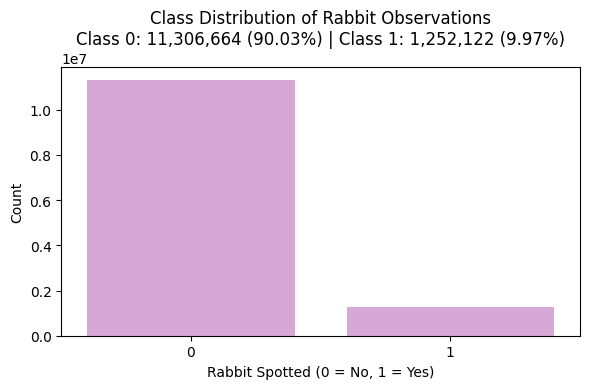

In [8]:
# Counts
counts = df['is_spotted'].value_counts().sort_index()
total = len(df)

count_0 = counts[0]
count_1 = counts[1]

pct_0 = count_0 / total * 100
pct_1 = count_1 / total * 100

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='is_spotted', color='plum')

plt.title(
    f'Class Distribution of Rabbit Observations\n'
    f'Class 0: {count_0:,} ({pct_0:.2f}%) | '
    f'Class 1: {count_1:,} ({pct_1:.2f}%)'
)

plt.xlabel('Rabbit Spotted (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

**Findings**

The target variable is_spotted is binary and was summarized using the number and percentage of observations in each class. The results show a clear class imbalance, with approximately 90% of observations belonging to class 0 (no rabbit sighting) and only 10% belonging to class 1 (rabbit sighting). This imbalance should be taken into account during model training and evaluation, for example by using appropriate evaluation metrics or class balancing techniques. 

### Habitats

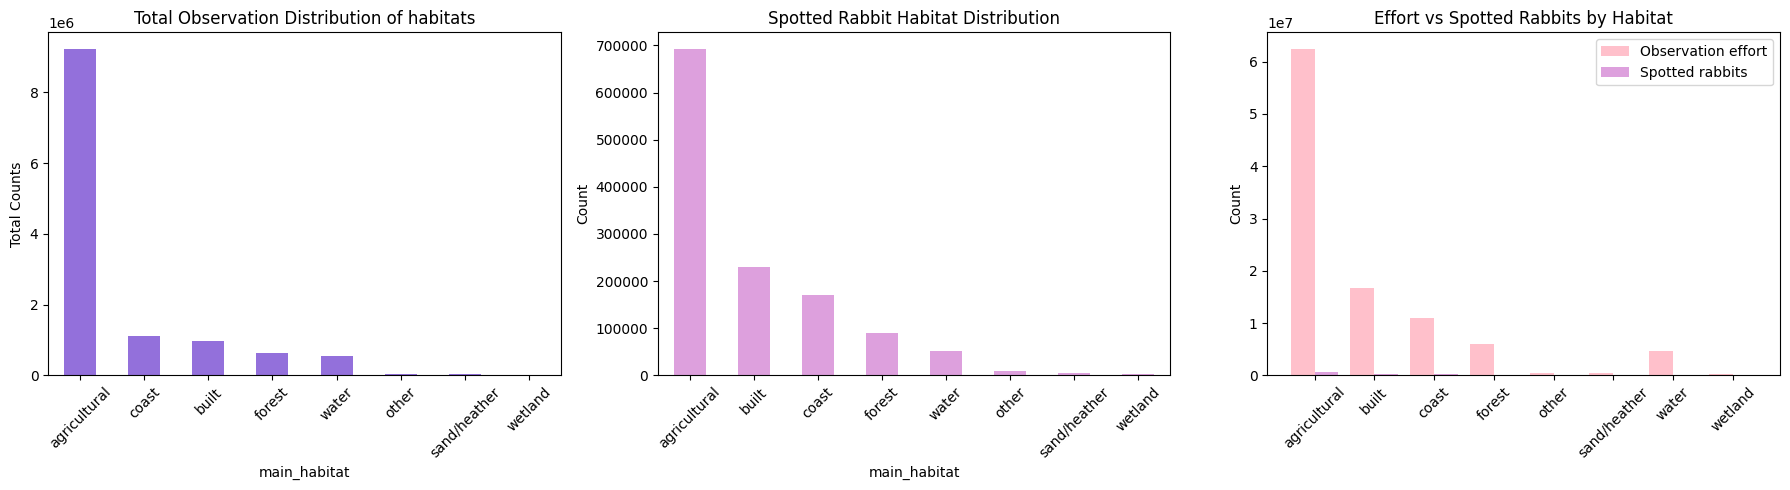

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Observation Distribution
df["main_habitat"].value_counts().plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Total Observation Distribution of habitats")
axes[0].set_ylabel("Total Counts")
axes[0].tick_params(axis='x', rotation=45)

# Spotted rabbit habitat distribution
df[df["is_spotted"] == 1]["main_habitat"].value_counts().plot(kind="bar", ax=axes[1], color="plum")
axes[1].set_title("Spotted Rabbit Habitat Distribution")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# COMBINED: effort + spotted per habitat
spotted = df[df["is_spotted"] == 1]["main_habitat"].value_counts()
effort = df.groupby("main_habitat")["total_observations"].sum()

# align indices
spotted = spotted.reindex(effort.index, fill_value=0)

x = np.arange(len(effort.index))
width = 0.4

axes[2].bar(x - width/2, effort.values, width=width, label="Observation effort", color="pink")
axes[2].bar(x + width/2, spotted.values, width=width, label="Spotted rabbits", color="plum")

axes[2].set_title("Effort vs Spotted Rabbits by Habitat")
axes[2].set_ylabel("Count")
axes[2].set_xticks(x)
axes[2].set_xticklabels(effort.index, rotation=45)
axes[2].legend()

plt.tight_layout()
plt.show()

**Findings**

From these bar charts we can clearly see that our target is mostly spotted in an agricultural habitat while we see from all the habitats there were the least amount of total observations in agricultural.This would indicate a strong sampling bias and that the agricultural habitat has a true higher rabbit presence. Yet if we look at the actual distribution we can see that most of our data is agricultural data, which could mean that less overall observations were made because there were less occurrences.

In [10]:
habitat_summary = df['main_habitat'].value_counts().reset_index()
habitat_summary.columns = ['Habitat', 'Count']
habitat_summary['Percentage'] = (habitat_summary['Count'] / habitat_summary['Count'].sum()) * 100

print(habitat_summary)

        Habitat    Count  Percentage
0  agricultural  9233520   73.522569
1         coast  1098672    8.748255
2         built   958416    7.631456
3        forest   631152    5.025593
4         water   543492    4.327594
5         other    40908    0.325733
6  sand/heather    29220    0.232666
7       wetland    23376    0.186133


**Findings**

Most common habitat in the Netherlands is agricultural

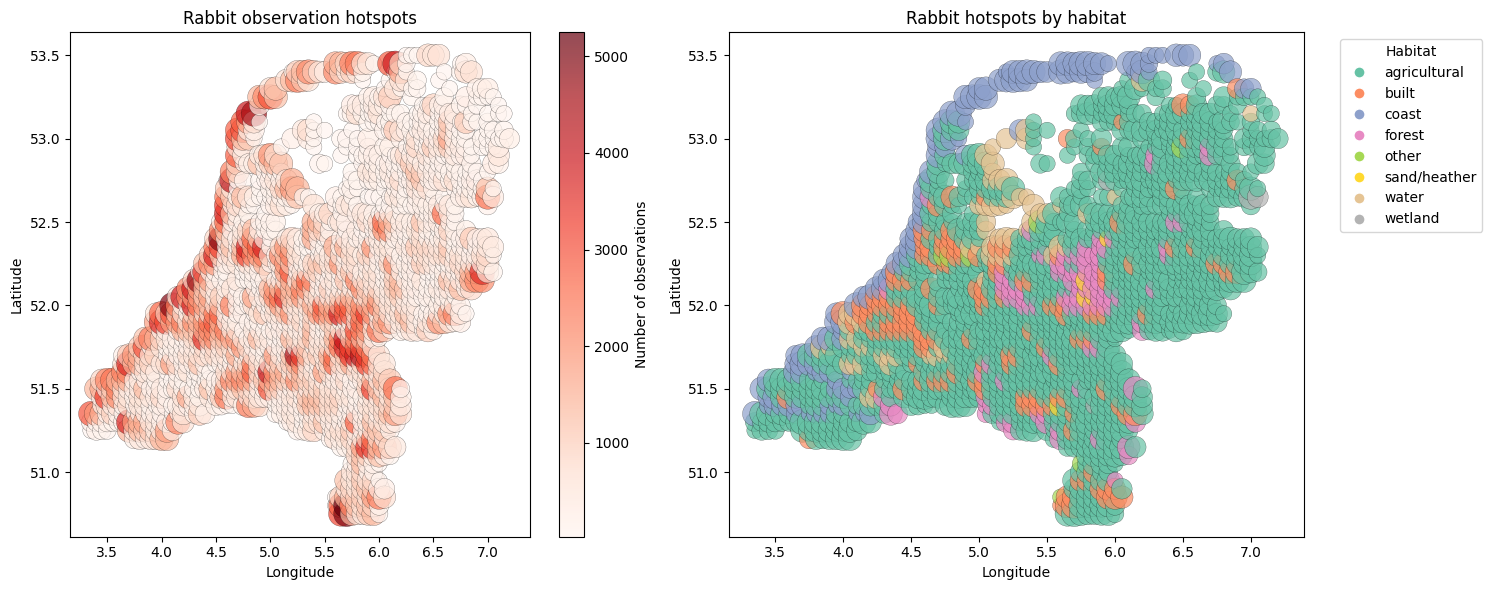

In [ ]:
df_spotted = df[df["is_spotted"] == 1]

# Location-only hotspot map
loc_counts_1 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude"]
).size().reset_index(name="count")

loc_counts_1["log_count"] = np.log1p(loc_counts_1["count"])

# Location + habitat map
loc_counts_2 = df_spotted.groupby(
    ["decimalLongitude", "decimalLatitude", "main_habitat"]
).size().reset_index(name="count")

loc_counts_2["log_count"] = np.log1p(loc_counts_2["count"])

habitats = loc_counts_2["main_habitat"].astype("category")
colors = habitats.cat.codes

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc1 = axes[0].scatter(
    loc_counts_1["decimalLongitude"],
    loc_counts_1["decimalLatitude"],
    s=loc_counts_1["log_count"] * 40,
    c=loc_counts_1["count"],
    cmap="Reds",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[0].set_title("Rabbit observation hotspots")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

cbar1 = plt.colorbar(sc1, ax=axes[0])
cbar1.set_label("Number of observations")

sc2 = axes[1].scatter(
    loc_counts_2["decimalLongitude"],
    loc_counts_2["decimalLatitude"],
    s=loc_counts_2["log_count"] * 40,
    c=colors,
    cmap="Set2",
    alpha=0.7,
    edgecolors="black",
    linewidths=0.2
)

axes[1].set_title("Rabbit hotspots by habitat")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

# Habitat legend
handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cm.Set2(i),
               markersize=8,
               label=cat)
    for i, cat in enumerate(habitats.cat.categories)
]

axes[1].legend(handles=handles, title="Habitat",
               bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Findings**

As you can see above lots of hotspots are located either in agricultural areas of coast environments

### Weather


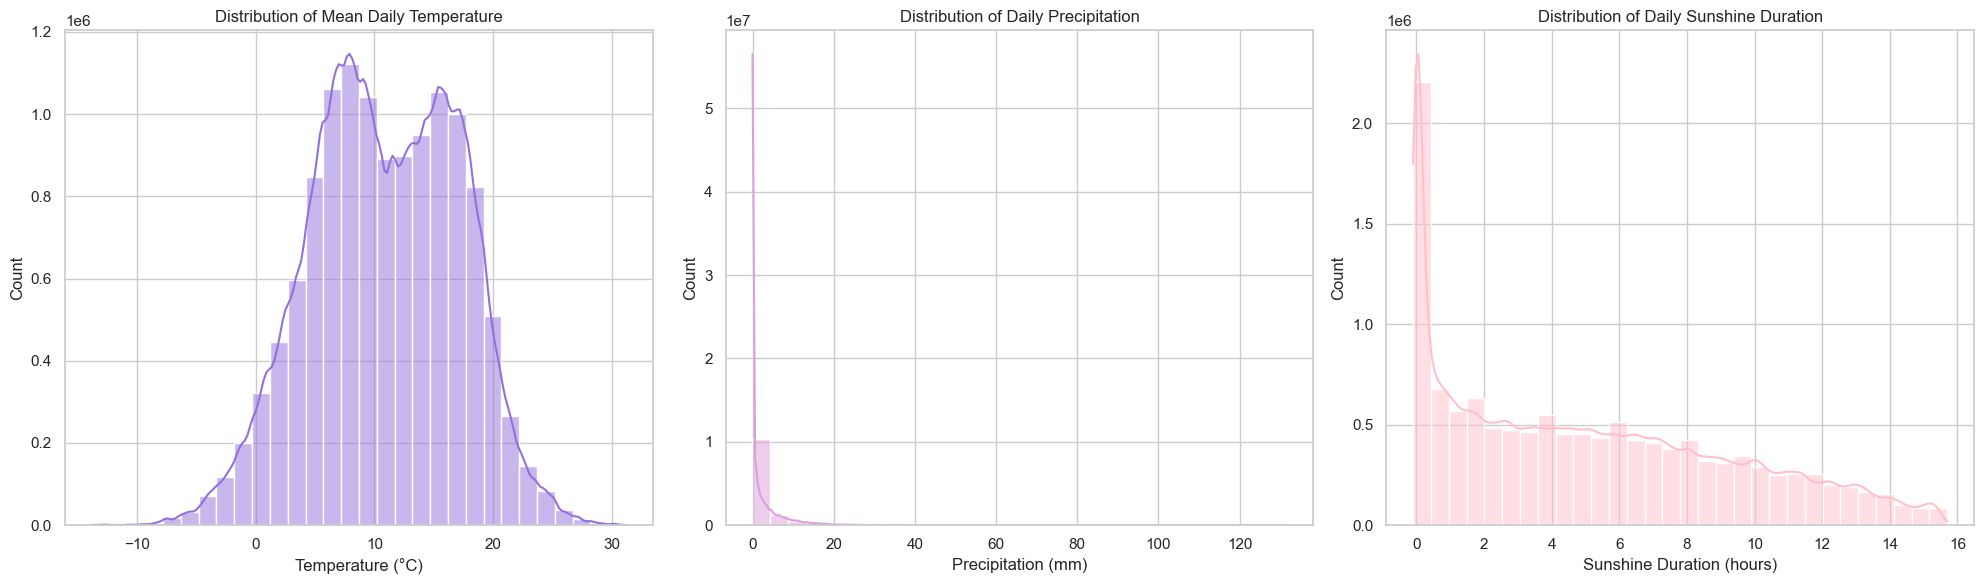

In [12]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram for Temperature
sns.histplot(df['temp_mean'], kde=True, ax=axes[0], color='mediumpurple', bins=30)
axes[0].set_title('Distribution of Mean Daily Temperature')
axes[0].set_xlabel('Temperature (°C)')

# Histogram for Precipitation
sns.histplot(df['precip_sum'], kde=True, ax=axes[1], color='plum', bins=30)
axes[1].set_title('Distribution of Daily Precipitation')
axes[1].set_xlabel('Precipitation (mm)')

# Histogram for Sunshine Duration
sns.histplot(df['sunshine_duration'], kde=True, ax=axes[2], color='pink', bins=30)
axes[2].set_title('Distribution of Daily Sunshine Duration')
axes[2].set_xlabel('Sunshine Duration (hours)')

plt.tight_layout()
plt.show()

**Findings**

The distributions reveal a temperate climate characterized by moderate temperatures and predominantly dry but often cloudy conditions. The mean daily temperature shows a bimodal pattern with prominent peaks around 8–12°C and 16–18°C, indicating two common temperature regimes likely driven by seasonal shifts, with most values ranging between -5°C and 25°C. Daily precipitation is heavily right-skewed, dominated by a massive spike at 0 mm, signifying that the majority of days are dry or experience minimal rainfall, though occasional heavy events extend beyond 100 mm. Similarly, sunshine duration exhibits strong right-skewness with the highest frequency at 0–2 hours, reflecting frequent overcast or cloudy skies, while fully sunny days reaching 14–16 hours are far less common. Overall, the data portrays a variable weather environment where dry and cloudy days prevail, punctuated by moderate temperatures and infrequent extremes in rain or sunshine.

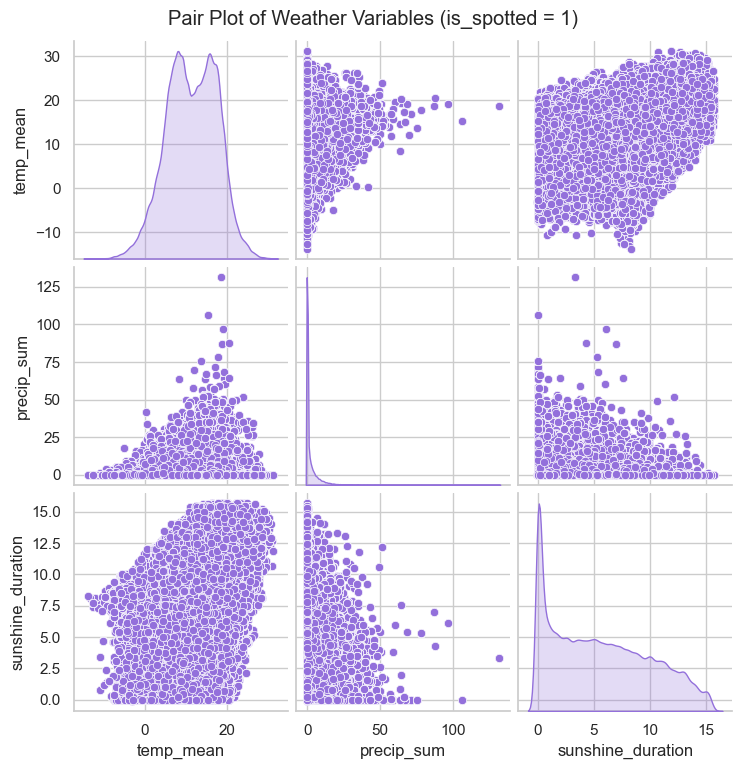

In [13]:
# Filter on only is_spotted true
df_spotted = df[df['is_spotted'] == 1]
plot_df = df_spotted[['temp_mean', 'precip_sum', 'sunshine_duration']]

sns.pairplot(
    plot_df, 
    diag_kind='kde', 
    plot_kws={'color': 'mediumpurple'}, 
    diag_kws={'color': 'mediumpurple'}
)

plt.suptitle('Pair Plot of Weather Variables (is_spotted = 1)', y=1.02)
plt.show()

**Findings** 

* The pair plot for days when spotting occurred reveals several interesting patterns in the weather conditions. Temperature and sunshine duration show a clear positive relationship: higher mean temperatures are generally associated with longer sunshine hours, forming a dense cluster between 5–15 hours of sunshine and 10–25°C.
* Precipitation displays a strong negative correlation with sunshine duration. As expected, days with higher rainfall tend to have significantly lower sunshine hours. Most spotted days had little to no precipitation, with the majority clustered near 0 mm.
* Interestingly, the temperature distribution on spotted days remains bimodal, with peaks around cooler (~5–10°C) and warmer (~20–25°C) conditions. There is also a noticeable concentration of spotting events in the mid-to-high temperature range (15–30°C) combined with moderate to high sunshine, while heavy precipitation days (>50 mm) are relatively rare on spotted days.
* Overall, spotting appears to favor warmer, sunnier, and drier days, though it still occurs across a fairly wide range of conditions, particularly in the absence of significant rainfall.

### Seasonal

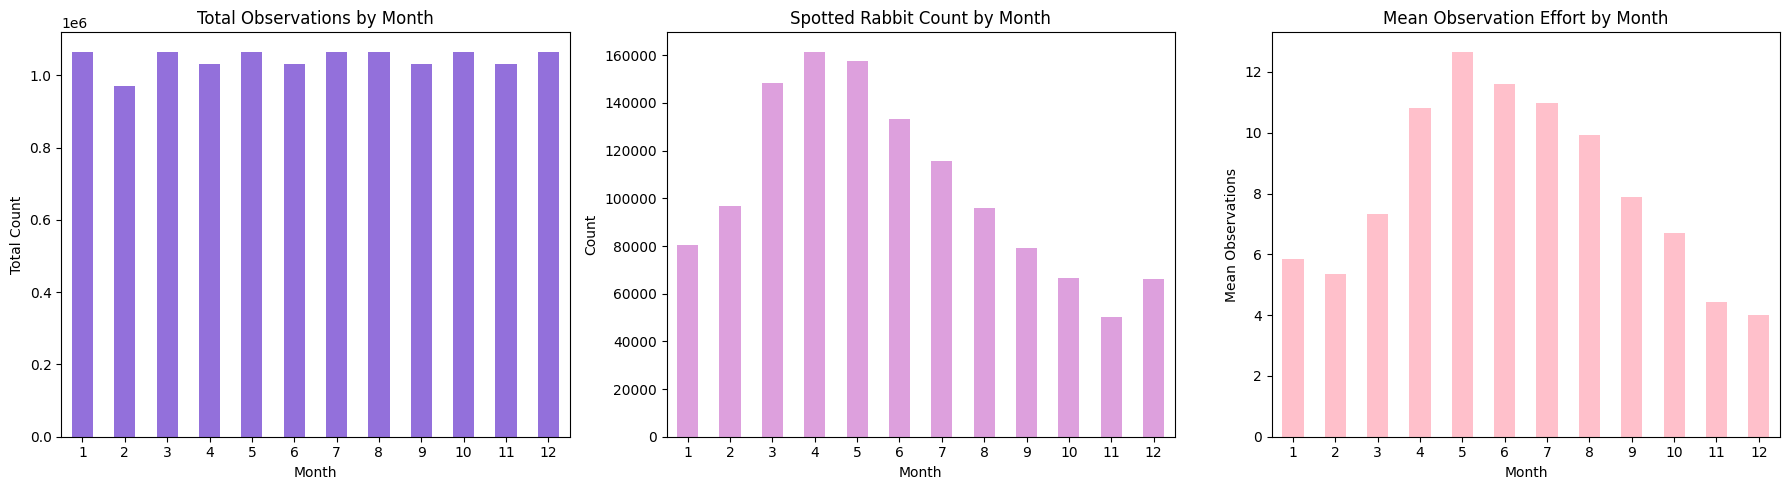

In [16]:
df["month"] = df["eventDate"].dt.month

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Observation Distribution by Month
df["month"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="mediumpurple")
axes[0].set_title("Total Observations by Month")
axes[0].set_ylabel("Total Count")
axes[0].set_xlabel("Month")
axes[0].tick_params(axis='x', rotation=0)

# Spotted rabbit distribution by Month
df[df["is_spotted"] == 1]["month"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="plum")
axes[1].set_title("Spotted Rabbit Count by Month")
axes[1].set_ylabel("Count")
axes[1].set_xlabel("Month")
axes[1].tick_params(axis='x', rotation=0)

# Mean observation effort by Month
df.groupby("month")["total_observations"].mean().sort_index().plot(kind="bar", ax=axes[2], color="pink")
axes[2].set_title("Mean Observation Effort by Month")
axes[2].set_ylabel("Mean Observations")
axes[2].set_xlabel("Month")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Findings** 

As we can see from the bar charts, the total observation count is fairly stable across the months. Both the rabbit count and the observation effort show a similar sinus-like pattern, with peaks in the same months and lower values in others. This could mean that rabbits do show a seasonal pattern, but it is also very possible that this pattern is influenced by changes in observation effort. Because effort and rabbit counts follow the same shape, the results may be partly biased, so it is hard to say how strong the seasonal trend is.


### Correlation Heatmaps

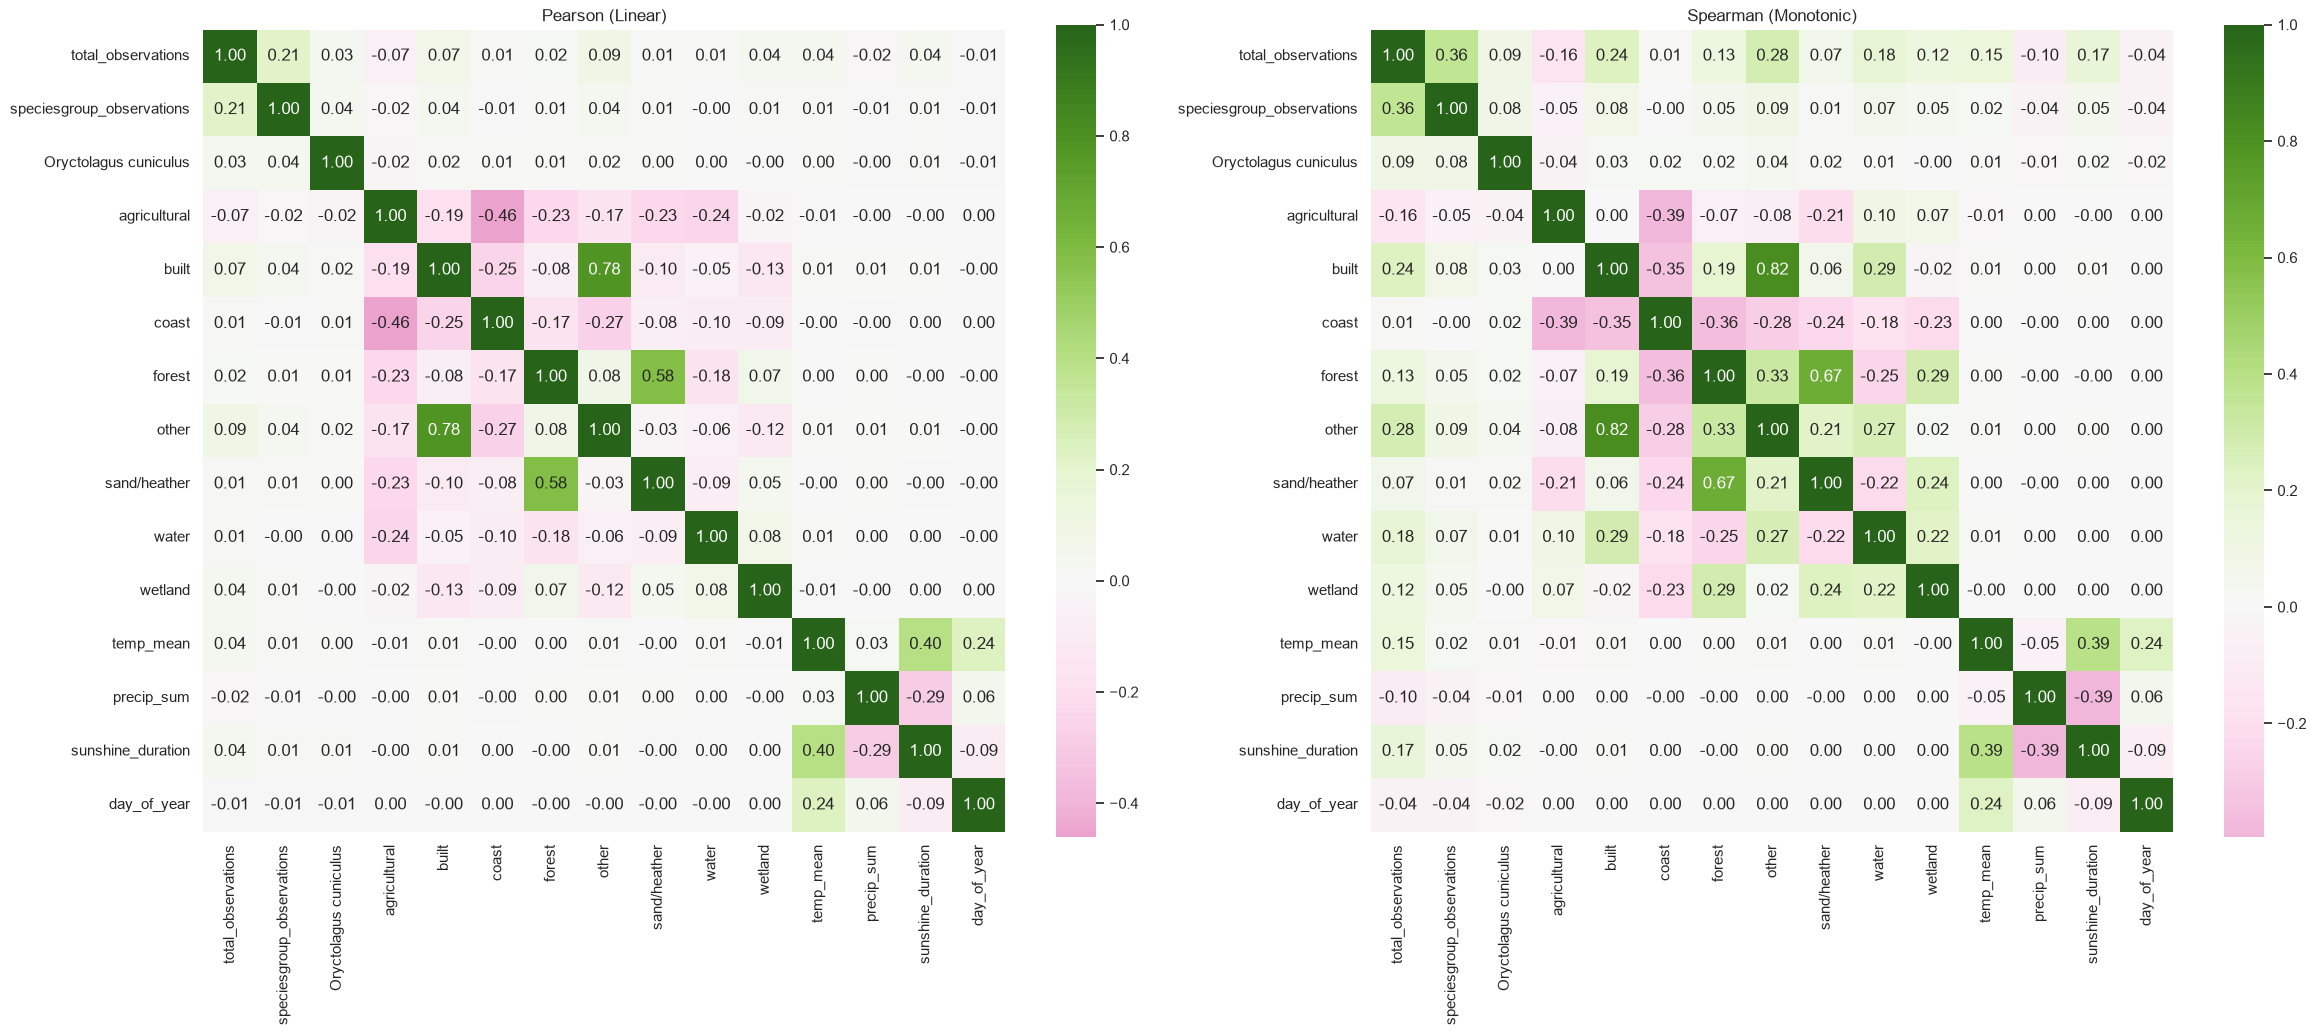

In [ ]:
# select features
features = [
    "total_observations",
    "speciesgroup_observations",
    "Oryctolagus cuniculus",
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_of_year"
]

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Pearson correlation heatmap
sns.heatmap(df[features].corr(), ax=axes[0], annot=True, fmt=".2f", cmap="PiYG", center=0, square=True)
axes[0].set_title("Pearson (Linear)")

# Spearman correlation heatmap
sns.heatmap(df[features].corr(method='spearman'), ax=axes[1], annot=True, fmt=".2f", cmap="PiYG", center=0, square=True)
axes[1].set_title("Spearman (Monotonic)")

plt.tight_layout()
plt.show()

**Findings**

Because all values in the is_spotted row are extremely close to zero, it can be concluded that there is no single linear feature that strongly predicts whether something is spotted. This suggests that the relationship between these features and is_spotted is likely non-linear or complex, and cannot be captured through simple correlation analysis.

### Line Charts
Too look for non-linear correlations

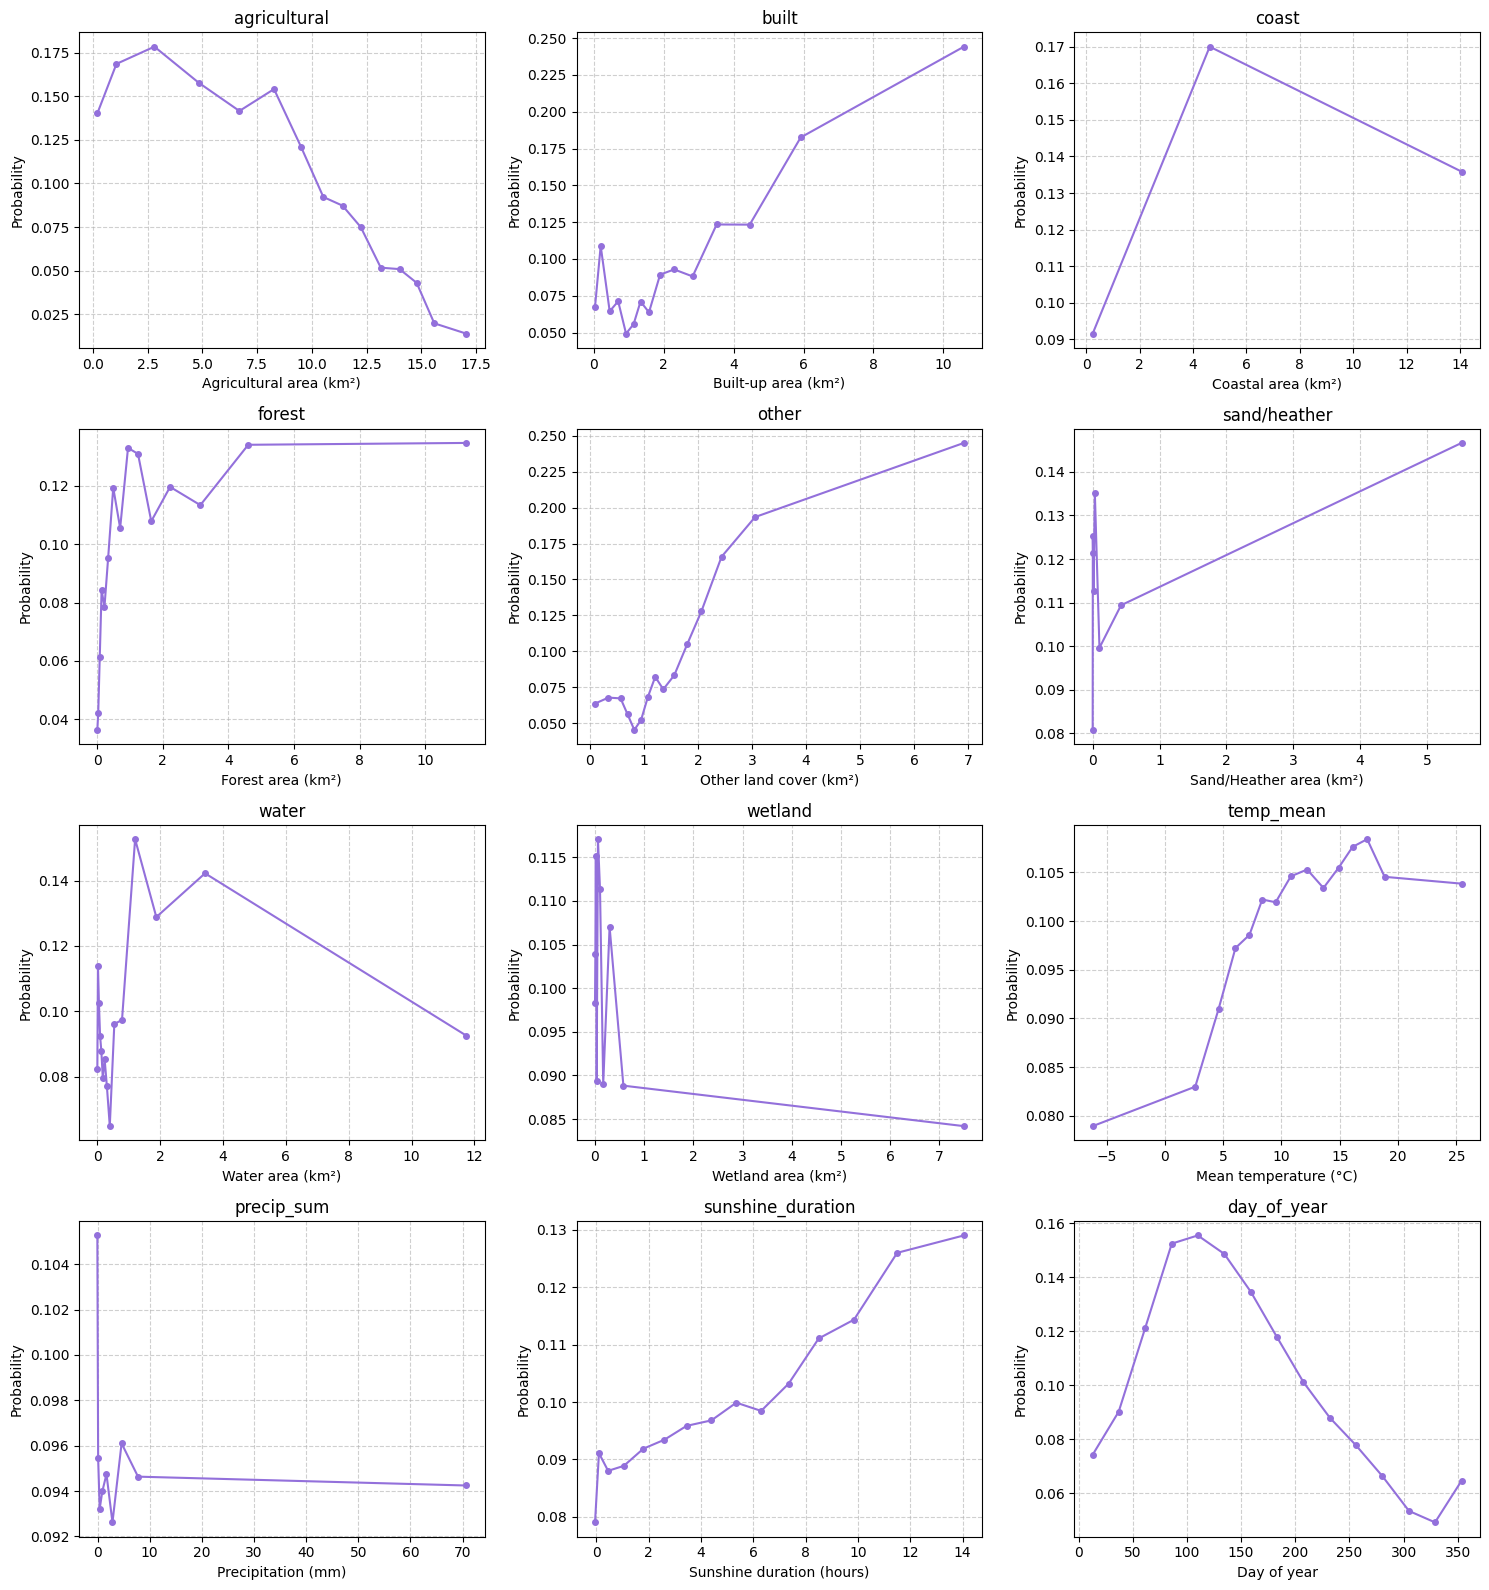

In [20]:
# Select features
features = [
    "agricultural", "built", "coast", "forest", "other", "sand/heather",
    "water", "wetland", "temp_mean", "precip_sum", "sunshine_duration", "day_of_year"
]

feature_labels = {
    "agricultural": "Agricultural area (km²)",
    "built": "Built-up area (km²)",
    "coast": "Coastal area (km²)",
    "forest": "Forest area (km²)",
    "other": "Other land cover (km²)",
    "sand/heather": "Sand/Heather area (km²)",
    "water": "Water area (km²)",
    "wetland": "Wetland area (km²)",
    "temp_mean": "Mean temperature (°C)",
    "precip_sum": "Precipitation (mm)",
    "sunshine_duration": "Sunshine duration (hours)",
    "day_of_year": "Day of year"
}

def plot_grid_overview(feature_list, df, bins=15, cols=3):
    # Calculate rows needed
    n_features = len(feature_list)
    rows = (n_features + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten() 
    
    for i, feature in enumerate(feature_list):
        if feature not in df.columns:
            continue
            
        # Binning logic
        df_plot = df.copy()
        try:
            df_plot['bin'] = pd.qcut(df_plot[feature], q=bins, duplicates='drop')
        except ValueError:
            df_plot['bin'] = pd.cut(df_plot[feature], bins=bins)
        
        grouped = df_plot.groupby('bin', observed=True)['is_spotted'].agg(['mean', 'count'])
        grouped = grouped[grouped['count'] > 50]
        x_values = [interval.mid for interval in grouped.index]
        
        # Plotting onto the specific axis
        axes[i].plot(x_values, grouped['mean'], marker='o', markersize=4, color='mediumpurple')
        axes[i].set_title(feature)
        axes[i].set_xlabel(feature_labels.get(feature, feature))
        axes[i].set_ylabel("Probability")
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

plot_grid_overview(features, df, cols=3)

**Findings**

The line plots were made by comparing multiple features with the mean of the target variable, is_spotted. Since is_spotted is a binary variable, the mean represents the probability of rabbit presence for different ranges of each feature. The x-axis shows the values of the feature, while the y-axis shows the average probability of rabbit presence.
From these line plots, it can be seen that several features have a non-linear relationship with the target. This means that the probability of rabbit presence does not increase or decrease at a constant rate as the feature values change. Because of this, models that can capture non-linear relationships are expected to perform better than simple linear models.


# 2.2 Data preparation

**Check duplicates, missing values or typos**

In [14]:
df.isnull().sum()

decimalLatitude                0
decimalLongitude               0
eventDate                      0
total_observations             3
speciesgroup_observations      0
Oryctolagus cuniculus          5
agricultural                  30
built                         30
coast                         30
forest                        30
other                         30
sand/heather                  30
water                         30
wetland                       30
main_habitat                  30
nearest_station                0
station_name                   0
temp_mean                    378
precip_sum                   378
sunshine_duration            547
spotted                        0
is_spotted                     0
day_of_year                    0
dtype: int64

In [26]:
# Check percentage of missing values
missing = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Percentage (%)": (df.isna().mean() * 100).round(3)
})

missing[missing["Missing values"] > 0]

,Missing values,Percentage (%)


In [ ]:
# Filling in the median for total_observations and forward filling for weather variables
df["total_observations"] = df["total_observations"].fillna(df["total_observations"].median())
df.sort_values(["decimalLatitude", "decimalLongitude"]) \
  .groupby(["decimalLatitude", "decimalLongitude"]) \
  [["temp_mean", "precip_sum", "sunshine_duration"]].ffill()
df = df.dropna()
#check for missing values
df.isnull().sum()

decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Oryctolagus cuniculus        0
agricultural                 0
built                        0
coast                        0
forest                       0
other                        0
sand/heather                 0
water                        0
wetland                      0
main_habitat                 0
nearest_station              0
station_name                 0
temp_mean                    0
precip_sum                   0
sunshine_duration            0
spotted                      0
is_spotted                   0
day_of_year                  0
dtype: int64

* *We removed all the zero values because when we took a closer look all the values were extreme and not similar at all to the rest of the data*

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
print(habitat["main_habitat"].unique())

<StringArray>
['agricultural',        'built',        'other',        'water',
       'forest',        'coast', 'sand/heather',      'wetland',
         'dirt']
Length: 9, dtype: str


In [ ]:
# Check weather variable distributions
weather_cols = ['temp_mean', 'precip_sum', 'sunshine_duration']
df[weather_cols].describe()

,temp_mean,precip_sum,sunshine_duration
count,1.255816e+07,1.255816e+07,1.255816e+07
mean,1.087058e+01,2.255325e+00,5.071840e+00
std,6.225568e+00,4.692605e+00,4.236424e+00
min,-1.380000e+01,-1.000000e-01,-1.000000e-01
25%,6.400000e+00,0.000000e+00,1.200000e+00
50%,1.080000e+01,1.000000e-01,4.400000e+00
75%,1.580000e+01,2.500000e+00,8.200000e+00
max,3.120000e+01,1.316000e+02,1.570000e+01


In [ ]:
# Devide weather variables by 10 to correct units
df['temp_mean'] = df['temp_mean'] / 10.0
df['precip_sum'] = df['precip_sum'] / 10.0
df['sunshine_duration'] = df['sunshine_duration'] / 10.0

# Scale weather variables with RobustScaler
scaler = RobustScaler()
df[weather_cols] = scaler.fit_transform(df[weather_cols])

# Show the scaled weather variable distributions
print("Weather variables scaled with RobustScaler after unit correction.")
print(df[weather_cols].describe())

Weather variables scaled with RobustScaler after unit correction.
          temp_mean    precip_sum  sunshine_duration
count  1.255816e+07  1.255816e+07       1.255816e+07
mean   7.508566e-03  8.621301e-01       9.597715e-02
std    6.622945e-01  1.877042e+00       6.052034e-01
min   -2.617021e+00 -8.000000e-02      -6.428571e-01
25%   -4.680851e-01 -4.000000e-02      -4.571429e-01
50%    0.000000e+00  0.000000e+00       0.000000e+00
75%    5.319149e-01  9.600000e-01       5.428571e-01
max    2.170213e+00  5.260000e+01       1.614286e+00


This code applies standard scaling to the KNMI weather variables (temp_mean, precip_sum, and sunshine_duration).

It transforms these features so they all have a mean of 0 and a standard deviation of 1. This ensures that variables with different units and ranges (°C, mm, hours) become comparable and no single variable dominates the analysis due to its scale.

It was implemented as a preprocessing step to improve data consistency across environmental features and to prepare the dataset for analysis or modelling where feature magnitude can influence results.

# 3. Modeling
**Model Validation Strategy**

In [21]:
# Select target variable
target = "is_spotted"

# Select features
features = [
    "total_observations",
    "speciesgroup_observations",
    "agricultural",
    "built",
    "coast",
    "forest",
    "other",
    "sand/heather",
    "water",
    "wetland",
    "temp_mean",
    "precip_sum",
    "sunshine_duration",
    "day_of_year"
]

# Columns we need but do not use as features
keep_cols = (
    features
    + [target, "eventDate", "decimalLatitude", "decimalLongitude", ]
)

df_model = df[keep_cols].copy()

df_model = df_model.dropna()

# Sort chronologically
df_model = df_model.sort_values("eventDate").reset_index(drop=True)


test_ratio = 0.20
split_idx = int(len(df_model) * (1 - test_ratio))

train = df_model.iloc[:split_idx].copy()
test = df_model.iloc[split_idx:].copy()


effort = (
    train.groupby(["decimalLatitude", "decimalLongitude"])[
        ["total_observations", "speciesgroup_observations"]
    ]
    .sum()
)

effort["observer_effort"] = (
    effort["total_observations"]
    + effort["speciesgroup_observations"]
)

effort = effort[["observer_effort"]].reset_index()

# Merge onto both datasets
train = train.merge(
    effort,
    on=["decimalLatitude", "decimalLongitude"],
    how="left"
)

test = test.merge(
    effort,
    on=["decimalLatitude", "decimalLongitude"],
    how="left"
)


# Quantiles based ONLY on training data
q1, q2, q3 = train["observer_effort"].quantile([0.25, 0.50, 0.75])

def categorize_effort(x):
    if pd.isna(x):
        return "unknown"
    elif x <= q1:
        return "low"
    elif x <= q2:
        return "medium"
    elif x <= q3:
        return "high"
    else:
        return "very_high"

train["observer_effort_cat"] = train["observer_effort"].apply(categorize_effort)
test["observer_effort_cat"] = test["observer_effort"].apply(categorize_effort)


train = pd.get_dummies(
    train,
    columns=["observer_effort_cat"],
    prefix="effort"
)

test = pd.get_dummies(
    test,
    columns=["observer_effort_cat"],
    prefix="effort"
)

# Make sure both have identical columns
train, test = train.align(test, join="left", axis=1, fill_value=0)


drop_cols = [
    target,
    "eventDate",
    "decimalLatitude",
    "decimalLongitude",
    "observer_effort"
]

X_train = train.drop(columns=drop_cols)
y_train = train[target]

X_test = test.drop(columns=drop_cols)
y_test = test[target]

print(X_train.shape)
print(X_test.shape)

print(X_train.filter(like="effort").head())

print(f"Train positive rate: {y_train.mean():.4f}")
print(f"Test positive rate : {y_test.mean():.4f}")
print(f"Observation effort quantiles (train): Q1={q1:.2f}, Q2={q2:.2f}, Q3={q3:.2f}")
print(f"Total observation counts (train): {len(train)}")

(10046524, 18)
(2511631, 18)
   effort_high  effort_low  effort_medium  effort_very_high
0         True       False          False             False
1        False       False          False              True
2        False        True          False             False
3        False       False           True             False
4        False       False          False              True
Train positive rate: 0.1112
Test positive rate : 0.0536
Observation effort quantiles (train): Q1=7965.00, Q2=17506.00, Q3=38042.00
Total observation counts (train): 10046524


We train test splitted the data into 80% training and 20% testing sets, while maintaining the same proportion of rabbit observations (is_spotted) in both sets.

Model

In [ ]:
# Baseline model
model1 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=50,
    class_weight='balanced',
    random_state=42
)

# Train
model1.fit(X_train, y_train)

# Predict
y_pred = model1.predict(X_test)

# Evaluate
print("Accuracy:")
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy:
0.7214399726711448
              precision    recall  f1-score   support

           0       0.98      0.72      0.83   2377035
           1       0.13      0.73      0.22    134596

    accuracy                           0.72   2511631
   macro avg       0.55      0.73      0.52   2511631
weighted avg       0.93      0.72      0.80   2511631

Recall: 0.7292267229338167

Confusion Matrix:
[[1713840  663195]
 [  36445   98151]]


In [ ]:
# XGBoost Classifier without hyperparameter tuning
model2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]),
    random_state=42,
    eval_metric='logloss'
)

# Train
model2.fit(X_train, y_train)

# Predict
y_pred = model2.predict(X_test)

# Evaluate
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1725400  651635]
 [  23611  110985]]
              precision    recall  f1-score   support

           0       0.99      0.73      0.84   2377035
           1       0.15      0.82      0.25    134596

    accuracy                           0.73   2511631
   macro avg       0.57      0.78      0.54   2511631
weighted avg       0.94      0.73      0.80   2511631



In [ ]:
# Calculate the class imbalance ratio dynamically
tscv = TimeSeriesSplit(n_splits=3)
# Instantiate the base model
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# Define the hyperparameter space to search
param_dist = {
    'n_estimators': [400, 600, 800, 1000],
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.08],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'reg_alpha': [0, 0.1, 0.5, 1],
    'reg_lambda': [1, 5, 10],
    'scale_pos_weight': [4, 6, 8, 10, 12, 15, 20, 25]   
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Run the hyperparameter search
print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# Extract the best model and parameters
best_model = random_search.best_estimator_
print("\n--- Tuning Complete ---")
print(f"Best Parameters Found: {random_search.best_params_}")
print(f"Best CV F1-Score: {random_search.best_score_:.4f}\n")

y_pred_tuned = best_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Tuning Complete ---
Best Parameters Found: {'subsample': 0.9, 'scale_pos_weight': 4, 'reg_lambda': 10, 'reg_alpha': 0.5, 'n_estimators': 800, 'min_child_weight': 7, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.6}
Best CV F1-Score: 0.4766

Confusion Matrix:
[[2071036  305999]
 [  49892   84704]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.87      0.92   2377035
           1       0.22      0.63      0.32    134596

    accuracy                           0.86   2511631
   macro avg       0.60      0.75      0.62   2511631
weighted avg       0.94      0.86      0.89   2511631



### testing out stuff


In [46]:
# Training set performance (for comparison)
y_pred_train = best_model.predict(X_train)
print("Training Set Performance")
print(classification_report(y_train, y_pred_train))

Training Set Performance
              precision    recall  f1-score   support

           0       0.95      0.89      0.92   8929067
           1       0.42      0.65      0.51   1117457

    accuracy                           0.86  10046524
   macro avg       0.69      0.77      0.71  10046524
weighted avg       0.89      0.86      0.87  10046524



Training Random Forest...

RANDOM FOREST RESULTS

Classification Report:
              precision    recall  f1-score   support

           0     0.9856    0.7183    0.8310   2377035
           1     0.1408    0.8150    0.2401    134596

    accuracy                         0.7235   2511631
   macro avg     0.5632    0.7667    0.5356   2511631
weighted avg     0.9404    0.7235    0.7994   2511631


ROC AUC Score: 0.8503


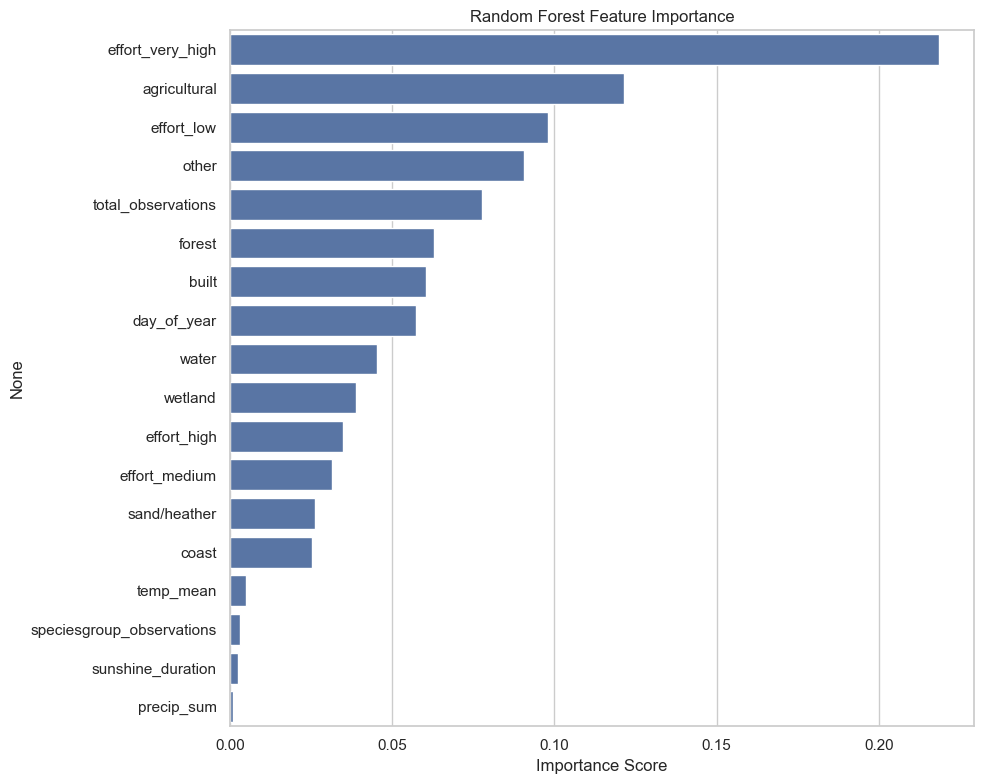


Top 10 Most Important Features:
effort_very_high      0.2184
agricultural          0.1215
effort_low            0.0981
other                 0.0905
total_observations    0.0778
forest                0.0628
built                 0.0605
day_of_year           0.0572
water                 0.0451
wetland               0.0388
dtype: float64


In [25]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced',
    bootstrap=True
)

print("Training Random Forest...")
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Feature Importance
importances = pd.Series(
    rf.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print(importances.head(10).round(4))

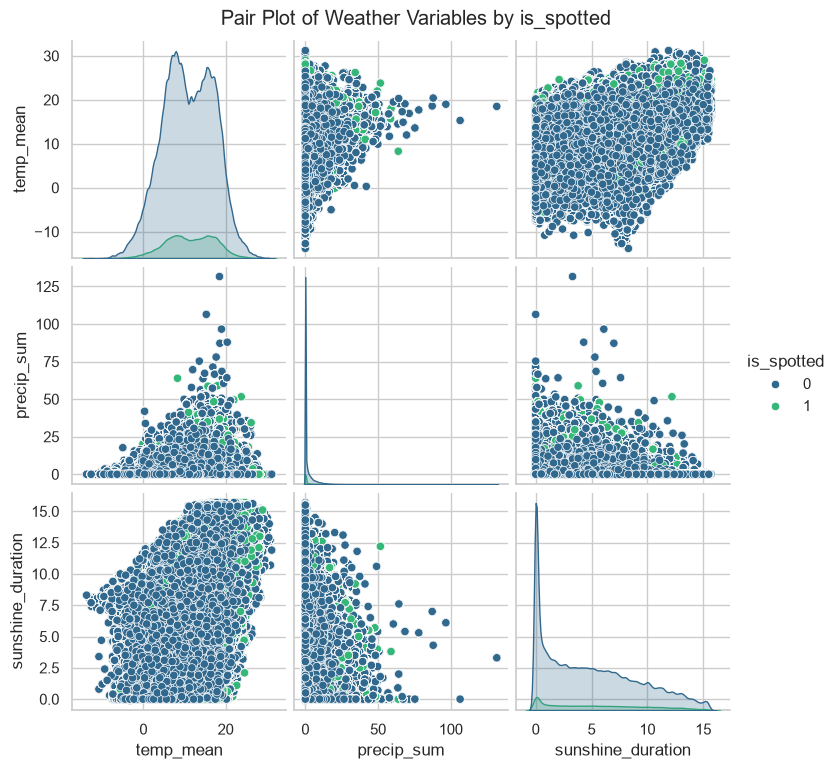

In [ ]:
plot_df = df[['temp_mean', 'precip_sum', 'sunshine_duration', 'is_spotted']]

# Generate the pairplot
sns.pairplot(plot_df, hue='is_spotted', diag_kind='kde', palette='viridis')

plt.suptitle('Pair Plot of Weather Variables by is_spotted', y=1.02)
plt.show()